In [334]:
import pandas as pd


telecom_churn = pd.read_csv('telecom_churn.csv', index_col = 0)
print(telecom_churn.shape)
print(telecom_churn.dtypes)
print(telecom_churn.isnull().sum())

(3333, 19)
account_length              int64
area_code                   int64
international_plan          int64
voice_mail_plan             int64
number_vmail_messages       int64
total_day_minutes         float64
total_day_calls             int64
total_day_charge          float64
total_eve_minutes         float64
total_eve_calls             int64
total_eve_charge          float64
total_night_minutes       float64
total_night_calls           int64
total_night_charge        float64
total_intl_minutes        float64
total_intl_calls            int64
total_intl_charge         float64
customer_service_calls      int64
churn                       int64
dtype: object
account_length            0
area_code                 0
international_plan        0
voice_mail_plan           0
number_vmail_messages     0
total_day_minutes         0
total_day_calls           0
total_day_charge          0
total_eve_minutes         0
total_eve_calls           0
total_eve_charge          0
total_night_minutes  

In [335]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X = telecom_churn[['total_day_charge', 'total_eve_charge', 'total_night_charge', 'customer_service_calls']]
y = telecom_churn['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)
print(f"Model accuracy: {accuracy}")


Model accuracy: 0.8785607196401799


In [336]:

X = telecom_churn[['total_day_charge', 'total_eve_charge', 'total_night_charge', 'customer_service_calls']]
y = telecom_churn['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15, stratify=y)

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)
print(f"Model accuracy: {accuracy}")

Model accuracy: 0.8764988009592326


In [337]:

X = telecom_churn[['total_day_charge', 'total_eve_charge', 'total_night_charge', 'customer_service_calls']]
y = telecom_churn['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15, stratify=y)

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)
print(f"Model accuracy: {accuracy}")

Model accuracy: 0.881


2.3 Answer: test_size 30% gives the best accuracy of 0.881.

1 0.833
2 0.865
3 0.875
4 0.882
5 0.886
6 0.882
7 0.889
8 0.881
9 0.886
10 0.878
11 0.881
12 0.882
13 0.884
14 0.881
15 0.881
16 0.882
17 0.88
18 0.879
19 0.88
20 0.878
21 0.88
22 0.878
23 0.883
24 0.88
25 0.882
Best k value: 7, Best accuracy: 0.889


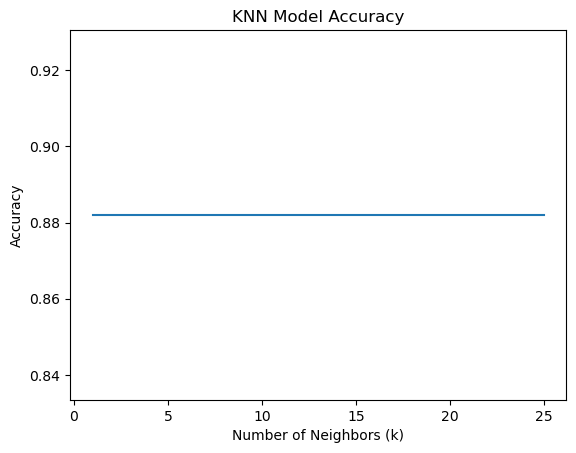

In [338]:
import matplotlib.pyplot as plt

best_k = 0
best_accuracy = 0

for k in range(1, 26):
    knn = KNeighborsClassifier(n_neighbors=k)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15, stratify=y)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)
    if accuracy > best_accuracy:
        best_k = k
        best_accuracy = accuracy
    print(k, accuracy)

print(f"Best k value: {best_k}, Best accuracy: {best_accuracy}")

plt.plot(range(1, 26), [knn.score(X_test, y_test) for k in range(1, 26)])
plt.title('KNN Model Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.show()


2.4 Answer: k value 7 gives the best accuracy

In [339]:
X = telecom_churn[['total_day_charge', 'total_eve_charge', 'total_night_charge', 'customer_service_calls']]
y = telecom_churn['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15, stratify=y)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)
print(f"Model accuracy: {accuracy}")

Model accuracy: 0.889


In [340]:
import numpy as np

X_new = np.array([[35.0, 17.5, 10.1, 1], [107.0, 19.0, 24.1, 0], [113.0, 9.9, 11.2, 2], [67.9, 5.7, 4.5, 1]])
predictions = knn.predict(X_new)
print(f"Predictions: {predictions}")

Predictions: [0 1 1 1]


c:\Users\LOQ\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


2.5 Answer: In my opinion, total_day_charge and customer_service_calls contribute to the churn.

In [341]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

cust_name = pd.read_csv('new_data.csv')

X_new = np.array(cust_name[['day_charge', 'eve_charge', 'night_charge', 'cust_service']])
predictions = knn.predict(X_new)
print(f"Prediction results: {predictions}")

churn_customers = cust_name[predictions == 1][['cust_name']]
print("Customers' names who will churn ", churn_customers)

Prediction results: [1 1 0 1 0 1 1 1 1 0 1 1 1 0]
Customers' names who will churn     cust_name
0        Tom
1      Peter
3       Jack
5       Levy
6        Kim
7      Worch
8      Gorge
10       Leo
11   Charles
12     Messi


c:\Users\LOQ\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
